# BLE IMU character recognition

In [1]:
from pathlib import Path
import pandas as pd

DATASET_ROOT = Path("prompted_BLE_dataset_5_WB")

SIGNAL_COLS = ["ax_g", "ay_g", "az_g", "gx_dps", "gy_dps", "gz_dps"]

def load_imu_csv(csv_path):
    meta = {}

    with open(csv_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        s = line.strip()

        if not s:
            continue

        if s.startswith("meta_"):
            parts = s.split(",", 1)
            if len(parts) == 2:
                meta[parts[0]] = parts[1]
            continue

        if s.startswith("count,"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Could not find data header in {csv_path}")

    df = pd.read_csv(csv_path, skiprows=header_idx)
    df = df[SIGNAL_COLS].apply(pd.to_numeric, errors="coerce").dropna()

    return meta, df

# Load dataset
samples = []
labels = []
paths = []

for csv_file in DATASET_ROOT.rglob("*.csv"):
    if csv_file.name == "manifest.csv":
        continue
    meta, df = load_imu_csv(csv_file)
    label = meta.get("meta_label", csv_file.stem[0])
    samples.append(df.values)
    labels.append(label)
    paths.append(csv_file)

print("Loaded", len(samples), "samples")
print("First label:", labels[0])
print("First sample shape:", samples[0].shape)

Loaded 3720 samples
First label: 0
First sample shape: (71, 6)


In [2]:
# Count samples in each class
from collections import Counter

counts = Counter(labels)

print("Number of classes:", len(counts))
print()

for cls in sorted(counts):
    print(f"{cls}: {counts[cls]}")

Number of classes: 62

0: 60
1: 60
2: 60
3: 60
4: 60
5: 60
6: 60
7: 60
8: 60
9: 60
A: 60
B: 60
C: 60
D: 60
E: 60
F: 60
G: 60
H: 60
I: 60
J: 60
K: 60
L: 60
M: 60
N: 60
O: 60
P: 60
Q: 60
R: 60
S: 60
T: 60
U: 60
V: 60
W: 60
X: 60
Y: 60
Z: 60
a: 60
b: 60
c: 60
d: 60
e: 60
f: 60
g: 60
h: 60
i: 60
j: 60
k: 60
l: 60
m: 60
n: 60
o: 60
p: 60
q: 60
r: 60
s: 60
t: 60
u: 60
v: 60
w: 60
x: 60
y: 60
z: 60


In [3]:
# Preprocessing

import numpy as np

def preprocess_sample(sample, center=True, add_magnitude=True):
    """
    sample shape: (T, 6)
    columns: ax, ay, az, gx, gy, gz
    """
    x = sample.astype(np.float32).copy()

    if center:
        x[:, :3] -= x[:, :3].mean(axis=0, keepdims=True)  # accel
        x[:, 3:6] -= x[:, 3:6].mean(axis=0, keepdims=True)  # gyro

    if add_magnitude:
        acc_mag = np.linalg.norm(x[:, :3], axis=1, keepdims=True)
        gyro_mag = np.linalg.norm(x[:, 3:6], axis=1, keepdims=True)
        x = np.hstack([x, acc_mag, gyro_mag])

    return x

processed_samples = [preprocess_sample(s, center=True, add_magnitude=True) for s in samples]

In [4]:
# Feature extractor

import numpy as np

def extract_features(sample):
    feats = []

    for i in range(sample.shape[1]):
        s = sample[:, i]

        feats.extend([
            np.mean(s),
            np.std(s),
            np.min(s),
            np.max(s),
            np.max(s) - np.min(s),
            np.sqrt(np.mean(s**2)),   # RMS
            np.sum(s**2),             # energy
            np.median(s),
        ])

    # sample duration / length can also help
    feats.append(sample.shape[0])

    return np.array(feats, dtype=np.float32)

In [5]:
# Build feature matrix
X = np.vstack([extract_features(s) for s in samples])
y = np.array(labels)

print(X.shape)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Classes:", le.classes_)

# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)

(3720, 49)
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z'
 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


In [6]:
# Classifier

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

Accuracy: 0.5806451612903226
              precision    recall  f1-score   support

           0       0.78      0.58      0.67        12
           1       0.50      0.50      0.50        12
           2       0.71      0.83      0.77        12
           3       0.69      0.92      0.79        12
           4       0.64      0.58      0.61        12
           5       0.62      0.83      0.71        12
           6       0.56      0.42      0.48        12
           7       0.79      0.92      0.85        12
           8       0.43      0.25      0.32        12
           9       0.70      0.58      0.64        12
           A       0.77      0.83      0.80        12
           B       0.38      0.50      0.43        12
           C       0.56      0.42      0.48        12
           D       0.43      0.25      0.32        12
           E       0.50      0.58      0.54        12
           F       0.58      0.92      0.71        12
           G       0.60      0.75      0.67        1

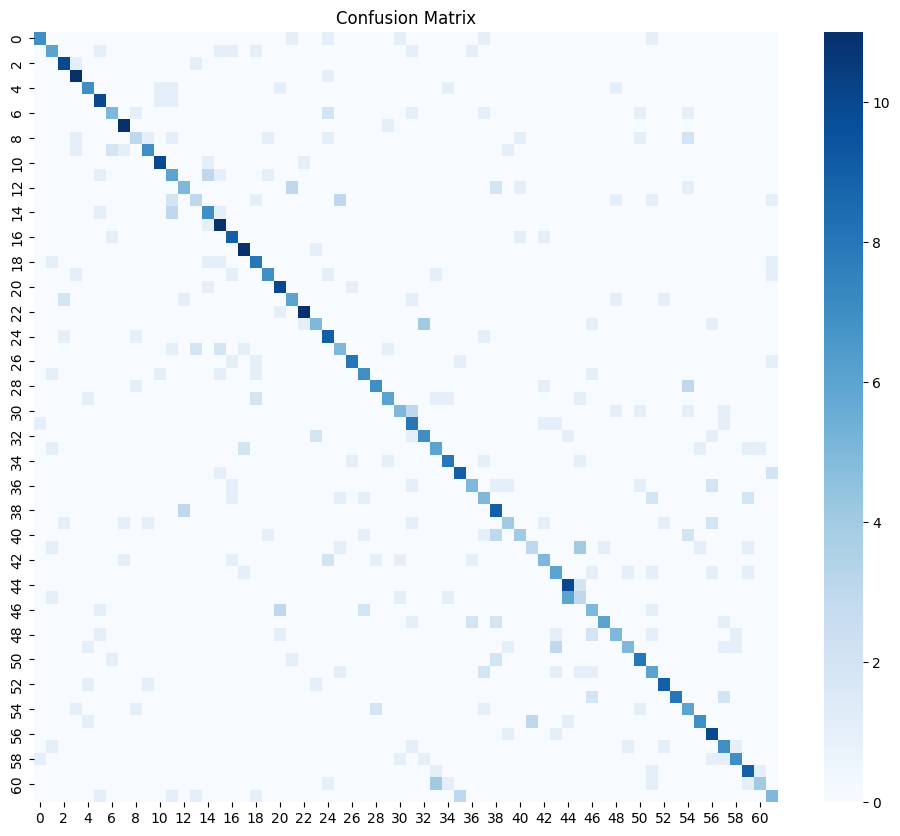

In [7]:
# Evaluate

from sklearn.metrics import accuracy_score, classification_report

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# CNN

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [9]:
def preprocess_sample(sample, center=True, add_magnitude=True):
    """
    sample shape: (T, 6)
    columns assumed: ax, ay, az, gx, gy, gz
    """
    x = sample.astype(np.float32).copy()

    if center:
        x[:, :3] -= x[:, :3].mean(axis=0, keepdims=True)   # accel bias / gravity-like offset
        x[:, 3:6] -= x[:, 3:6].mean(axis=0, keepdims=True) # gyro bias

    if add_magnitude:
        acc_mag = np.linalg.norm(x[:, :3], axis=1, keepdims=True)
        gyro_mag = np.linalg.norm(x[:, 3:6], axis=1, keepdims=True)
        x = np.hstack([x, acc_mag, gyro_mag])  # shape becomes (T, 8)

    return x


def resample_sequence(seq, target_len=64):
    """
    seq: (T, C)
    returns: (target_len, C)
    """
    T, C = seq.shape
    if T == target_len:
        return seq.astype(np.float32)

    old_idx = np.linspace(0, 1, T)
    new_idx = np.linspace(0, 1, target_len)

    out = np.zeros((target_len, C), dtype=np.float32)
    for c in range(C):
        out[:, c] = np.interp(new_idx, old_idx, seq[:, c])

    return out

In [10]:
# TARGET LEN DEFINED HERE

TARGET_LEN = 128

X_list = []
for s in samples:
    x = preprocess_sample(s, center=True, add_magnitude=True)
    x = resample_sequence(x, target_len=TARGET_LEN)
    X_list.append(x)

X = np.stack(X_list).astype(np.float32)   # shape: (N, 64, 8)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num classes:", len(set(y)))
print("Example label:", y[0])

X shape: (3720, 128, 8)
y shape: (3720,)
Num classes: 62
Example label: 0


In [11]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

num_classes = len(le.classes_)
print("Classes:", num_classes)
print(le.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_enc,
    test_size=0.30,
    stratify=y_enc,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Classes: 62
['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z'
 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']
Train: (2604, 128, 8) (2604,)
Val:   (558, 128, 8) (558,)
Test:  (558, 128, 8) (558,)


In [12]:
channel_mean = X_train.mean(axis=(0, 1), keepdims=True)
channel_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - channel_mean) / channel_std
X_val_n   = (X_val   - channel_mean) / channel_std
X_test_n  = (X_test  - channel_mean) / channel_std

print("Normalized shapes:")
print(X_train_n.shape, X_val_n.shape, X_test_n.shape)

Normalized shapes:
(2604, 128, 8) (558, 128, 8) (558, 128, 8)


In [13]:
from tensorflow import keras
from tensorflow.keras import layers

def build_cnn(input_shape, num_classes):
    reg = keras.regularizers.l2(1e-4)

    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(
            32, kernel_size=5, padding="same", activation="relu",
            kernel_regularizer=reg
        ),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        layers.Conv1D(
            64, kernel_size=5, padding="same", activation="relu",
            kernel_regularizer=reg
        ),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        layers.Conv1D(
            128, kernel_size=3, padding="same", activation="relu",
            kernel_regularizer=reg
        ),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        layers.GlobalAveragePooling1D(),

        layers.Dense(
            128, activation="relu",
            kernel_regularizer=reg
        ),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [14]:
def build_cnn_bilstm(input_shape, num_classes):
    reg = keras.regularizers.l2(1e-4)

    inp = keras.Input(shape=input_shape)

    x = layers.Conv1D(32, 5, padding="same", activation="relu", kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(64, 5, padding="same", activation="relu", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [15]:
# Build model

# model = build_cnn(input_shape=X_train_n.shape[1:], num_classes=num_classes)
model = build_cnn_bilstm(input_shape=X_train_n.shape[1:], num_classes=num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 128, 32)        │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,558 (400.62 KB)

 Trainable params: 102,366 (399.87 KB)

 Non-trainable params: 192 (768.00 B)

In [16]:
def train_generator(X, y, batch_size=32):
    n = len(X)

    while True:
        idx = np.random.permutation(n)

        for i in range(0, n, batch_size):
            batch_idx = idx[i:i+batch_size]

            X_batch = []
            for j in batch_idx:
                x = augment_sequence(X[j])
                X_batch.append(x)

            X_batch = np.stack(X_batch)
            y_batch = y[batch_idx]

            yield X_batch, y_batch

In [17]:
import numpy as np

def augment_sequence(x, noise_std=0.02, scale_range=(0.9, 1.1), shift_max=3):
    """
    x: (T, C)
    returns augmented copy
    """
    y = x.copy()

    # amplitude scaling
    scale = np.random.uniform(scale_range[0], scale_range[1], size=(1, y.shape[1]))
    y = y * scale

    # additive noise
    y += np.random.normal(0, noise_std, size=y.shape).astype(np.float32)

    # temporal shift
    shift = np.random.randint(-shift_max, shift_max + 1)
    if shift > 0:
        y = np.pad(y, ((shift, 0), (0, 0)), mode="edge")[:len(y)]
    elif shift < 0:
        y = np.pad(y, ((0, -shift), (0, 0)), mode="edge")[-shift:]

    return y.astype(np.float32)

In [18]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=12,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        verbose=1
    )
]


# history = model.fit(
#     X_train_n, y_train,
#     validation_data=(X_val_n, y_val),
#     epochs=80,
#     batch_size=32,
#     callbacks=callbacks,
#     verbose=1
# )

batch_size = 32

steps = len(X_train_n) // batch_size

history = model.fit(
    train_generator(X_train_n, y_train, batch_size),
    steps_per_epoch=steps,
    validation_data=(X_val_n, y_val),
    epochs=80,
    callbacks=callbacks
)

Epoch 1/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.0378 - loss: 4.0623 - val_accuracy: 0.0430 - val_loss: 3.9425 - learning_rate: 0.0010
Epoch 2/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1322 - loss: 3.2994 - val_accuracy: 0.4462 - val_loss: 2.5747 - learning_rate: 0.0010
Epoch 3/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3371 - loss: 2.2180 - val_accuracy: 0.6792 - val_loss: 1.3858 - learning_rate: 0.0010
Epoch 4/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5070 - loss: 1.5543 - val_accuracy: 0.7939 - val_loss: 0.8177 - learning_rate: 0.0010
Epoch 5/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6380 - loss: 1.1253 - val_accuracy: 0.8351 - val_loss: 0.5284 - learning_rate: 0.0010
Epoch 6/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6886 - loss: 0.9325 - val_accuracy: 0.8763 - val_loss: 0.4234 - learning_rate: 0.0010
Epoch 7/80
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7624 - loss: 0.7363 - val_acc

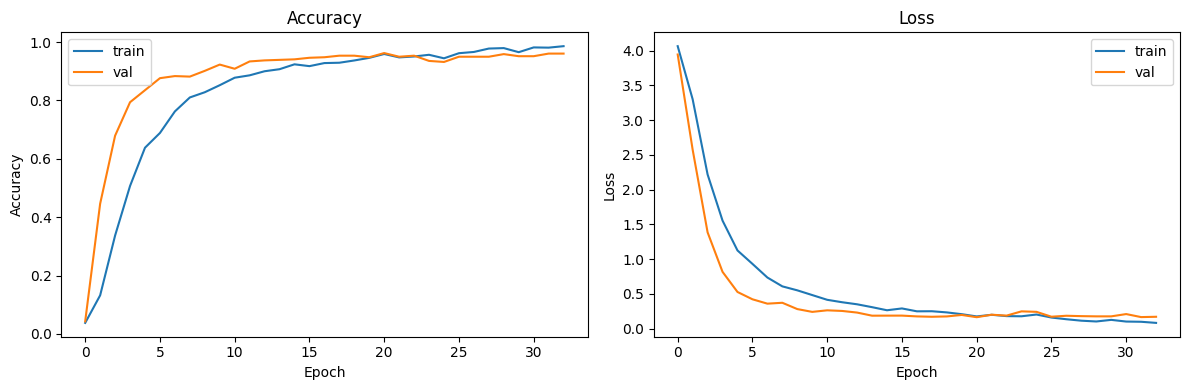

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Test accuracy: 0.9767025113105774
              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00         9
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         9
           7       1.00      1.00      1.00         9
           8       1.00      1.00      1.00         9
           9       1.00      1.00      1.00         9
           A       1.00      1.00      1.00         9
           B       1.00      1.00      1.00         9
           C       1.00      1.00      1.00         9
           D       1.00      1.00      1.00         9
           E       0.90      1.00      0.95         9
           F       1.00      0.89      0.94         9
           G       1.00      1.00      1.00    

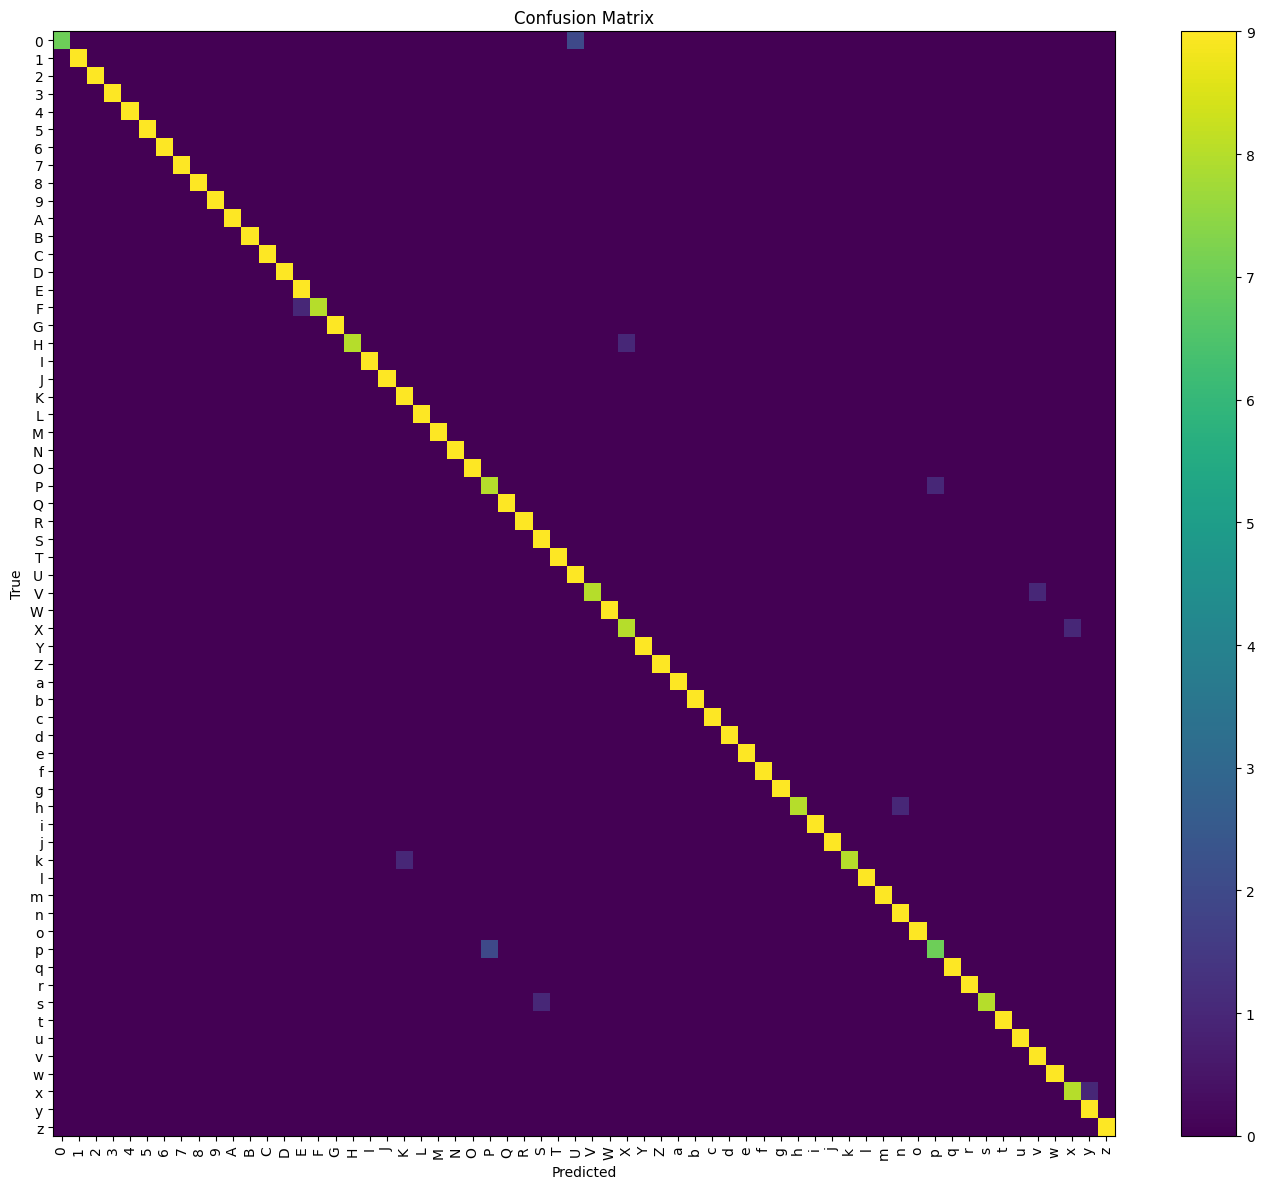

In [20]:
test_loss, test_acc = model.evaluate(X_test_n, y_test, verbose=0)
print("Test accuracy:", test_acc)

y_prob = model.predict(X_test_n, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation="nearest", aspect="auto")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(num_classes), le.classes_, rotation=90)
plt.yticks(np.arange(num_classes), le.classes_)
plt.tight_layout()
plt.show()

In [21]:
idxs = np.random.choice(len(X_test_n), size=min(15, len(X_test_n)), replace=False)

for idx in idxs:
    true_label = le.inverse_transform([y_test[idx]])[0]
    pred_label = le.inverse_transform([y_pred[idx]])[0]
    conf = y_prob[idx].max()
    print(f"true={true_label}  pred={pred_label}  conf={conf:.3f}")

true=c  pred=c  conf=0.999
true=x  pred=x  conf=0.790
true=R  pred=R  conf=0.994
true=S  pred=S  conf=0.783
true=H  pred=H  conf=0.985
true=8  pred=8  conf=0.999
true=Z  pred=Z  conf=0.519
true=m  pred=m  conf=0.996
true=C  pred=C  conf=0.996
true=M  pred=M  conf=0.999
true=z  pred=z  conf=0.971
true=Q  pred=Q  conf=1.000
true=q  pred=q  conf=1.000
true=v  pred=v  conf=0.983
true=W  pred=W  conf=0.987


In [ ]:
# from pathlib import Path
# from datetime import datetime
# import numpy as np

# # create timestamp
# ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# # create directory
# save_dir = Path("BLE_model_runs") / f"98_acc_128len_cnnbilstm_run_{ts}"
# save_dir.mkdir(parents=True, exist_ok=True)

# # save artifacts
# model.save(save_dir / "imu_char_cnn.keras")
# np.save(save_dir / "channel_mean.npy", channel_mean)
# np.save(save_dir / "channel_std.npy", channel_std)
# np.save(save_dir / "label_classes.npy", le.classes_)

# import json

# meta = {
#     "test_accuracy": float(test_acc),
#     "target_len": TARGET_LEN,
#     "num_classes": int(num_classes),
# }

# with open(save_dir / "metadata.json", "w") as f:
#     json.dump(meta, f, indent=2)

# print("Saved to:", save_dir)

Saved to: BLE_model_runs\98_acc_128len_cnnbilstm_run_20260413_111857


In [23]:
# # Load model

# model = keras.models.load_model(run_dir / "imu_char_cnn.keras")

# channel_mean = np.load(run_dir / "channel_mean.npy")
# channel_std = np.load(run_dir / "channel_std.npy")
# classes = np.load(run_dir / "label_classes.npy", allow_pickle=True)